Important libraries

In [84]:
%matplotlib inline
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [85]:
tzdata = pd.read_csv("tz_economic_predictors.csv")

In [86]:
tzdata.tail()

,month,inflation_pct,usd_tzs_rate,brent_oil_usd,m2_bn_tzs,bot_policy_rate_pct
96,Jan-26,3.262193,2467.820116,66.766,4.835311e+07,5.75
97,Feb-26,3.152958,2556.903379,71.114,4.849959e+07,5.75
98,Mar-26,3.158304,2570.410597,103.689,4.924827e+07,5.75
99,Apr-26,4.035298,2597.507093,120.423,5.010292e+07,5.75
100,May-26,4.215514,2602.516677,107.540,5.137532e+07,5.75


In [87]:
tzdata["month"] = pd.to_datetime(tzdata["month"], format="%b-%y")
tzdata = tzdata.sort_values("month").reset_index(drop=True)
# tzdata["month"] = (tzdata["month"].dt.year - 2000) * 12 + tzdata["month"].dt.month

# # option 2
# tzdata["date"] = pd.to_datetime(tzdata["month"], format="%b-%y")
# tzdata["year"] = tzdata["date"].dt.year
# tzdata["month"] = tzdata["date"].dt.month
# tzdata = tzdata.drop("date",axis=1)


In [88]:
tzdata["month"].unique()

<DatetimeArray>
['2018-01-01 00:00:00', '2018-02-01 00:00:00', '2018-03-01 00:00:00',
 '2018-04-01 00:00:00', '2018-05-01 00:00:00', '2018-06-01 00:00:00',
 '2018-07-01 00:00:00', '2018-08-01 00:00:00', '2018-09-01 00:00:00',
 '2018-10-01 00:00:00',
 ...
 '2025-08-01 00:00:00', '2025-09-01 00:00:00', '2025-10-01 00:00:00',
 '2025-11-01 00:00:00', '2025-12-01 00:00:00', '2026-01-01 00:00:00',
 '2026-02-01 00:00:00', '2026-03-01 00:00:00', '2026-04-01 00:00:00',
 '2026-05-01 00:00:00']
Length: 101, dtype: datetime64[us]

# Visualization

In [89]:
tzdata.isnull().sum()

month                  0
inflation_pct          0
usd_tzs_rate           0
brent_oil_usd          0
m2_bn_tzs              0
bot_policy_rate_pct    0
dtype: int64

In [90]:
tzdata.info()

<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   month                101 non-null    datetime64[us]
 1   inflation_pct        101 non-null    float64       
 2   usd_tzs_rate         101 non-null    float64       
 3   brent_oil_usd        101 non-null    float64       
 4   m2_bn_tzs            101 non-null    float64       
 5   bot_policy_rate_pct  101 non-null    float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 4.9 KB


In [91]:
# Explanatory Analysis
tzdata.describe()

,month,inflation_pct,usd_tzs_rate,brent_oil_usd,m2_bn_tzs,bot_policy_rate_pct
count,101,101.000000,101.000000,101.000000,1.010000e+02,101.000000
mean,2022-03-02 01:11:17.227722,3.556853,2382.952666,73.676584,2.902113e+07,10.235149
min,2018-01-01 00:00:00,3.000000,2250.800000,18.380000,1.807449e+07,5.500000
25%,2020-02-01 00:00:00,3.200000,2291.300000,64.220000,2.126275e+07,6.000000
50%,2022-03-01 00:00:00,3.400000,2299.200000,73.830000,2.706221e+07,12.000000
75%,2024-04-01 00:00:00,3.800000,2477.153603,82.710000,3.413008e+07,12.000000
max,2026-05-01 00:00:00,4.900000,2718.500000,122.710000,5.137532e+07,12.000000
std,NaN,0.515709,133.763077,18.494119,8.986129e+06,2.796163


Encoding

In [92]:
tzdata.tail()

,month,inflation_pct,usd_tzs_rate,brent_oil_usd,m2_bn_tzs,bot_policy_rate_pct
96,2026-01-01,3.262193,2467.820116,66.766,4.835311e+07,5.75
97,2026-02-01,3.152958,2556.903379,71.114,4.849959e+07,5.75
98,2026-03-01,3.158304,2570.410597,103.689,4.924827e+07,5.75
99,2026-04-01,4.035298,2597.507093,120.423,5.010292e+07,5.75
100,2026-05-01,4.215514,2602.516677,107.540,5.137532e+07,5.75


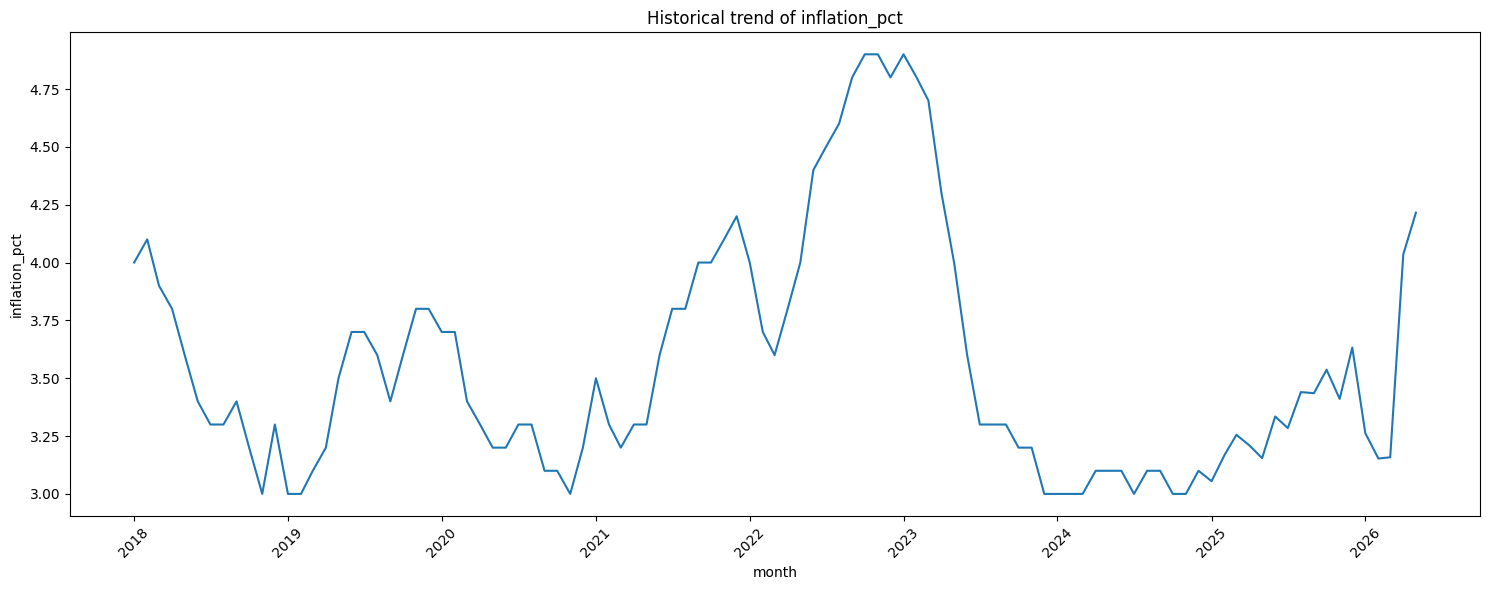

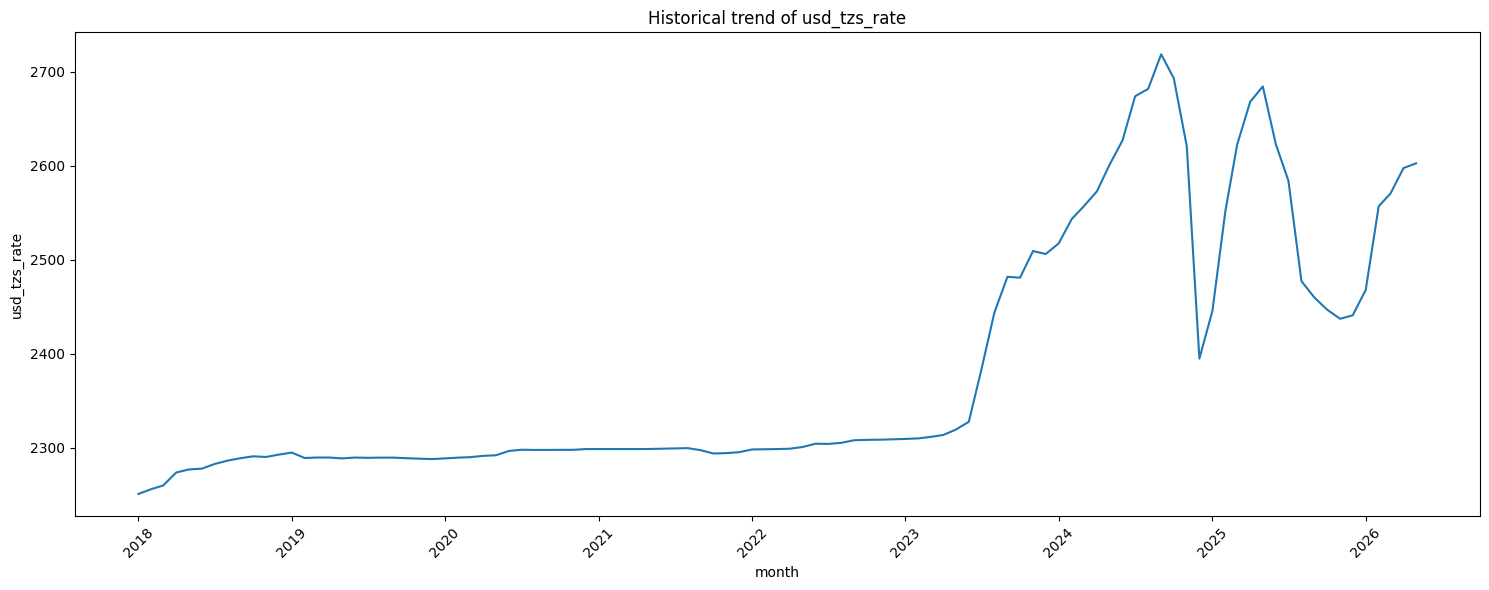

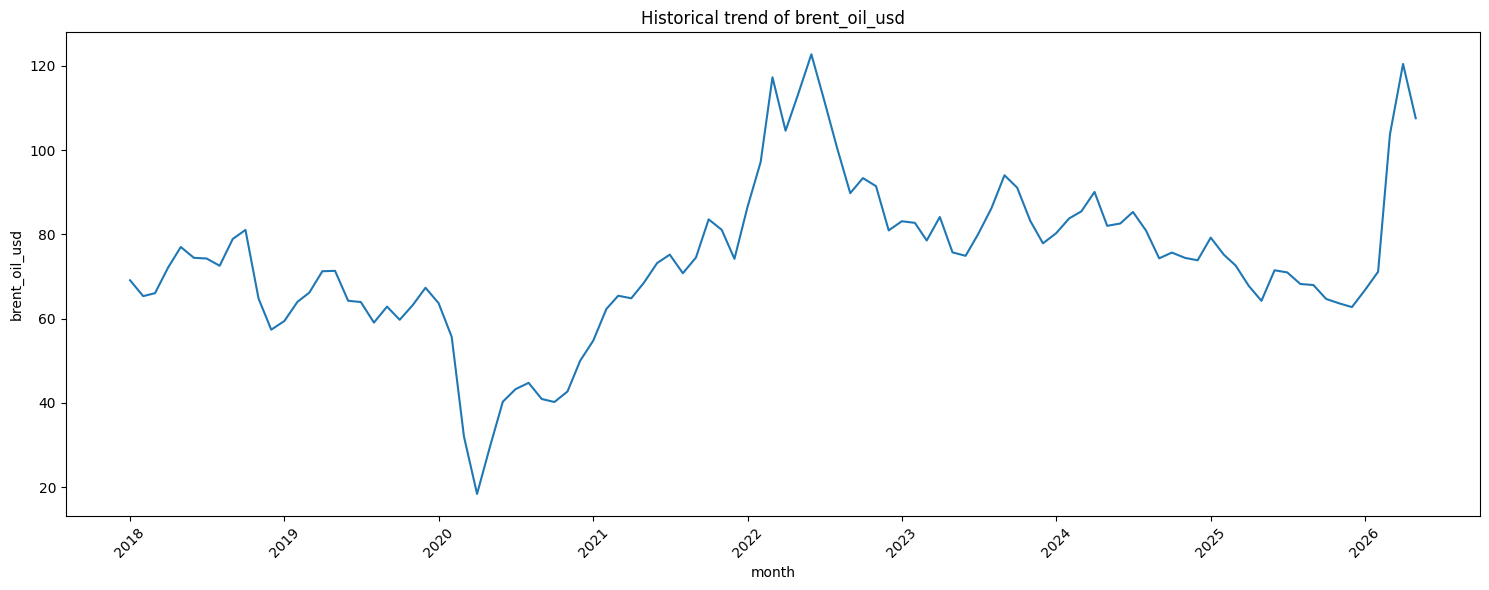

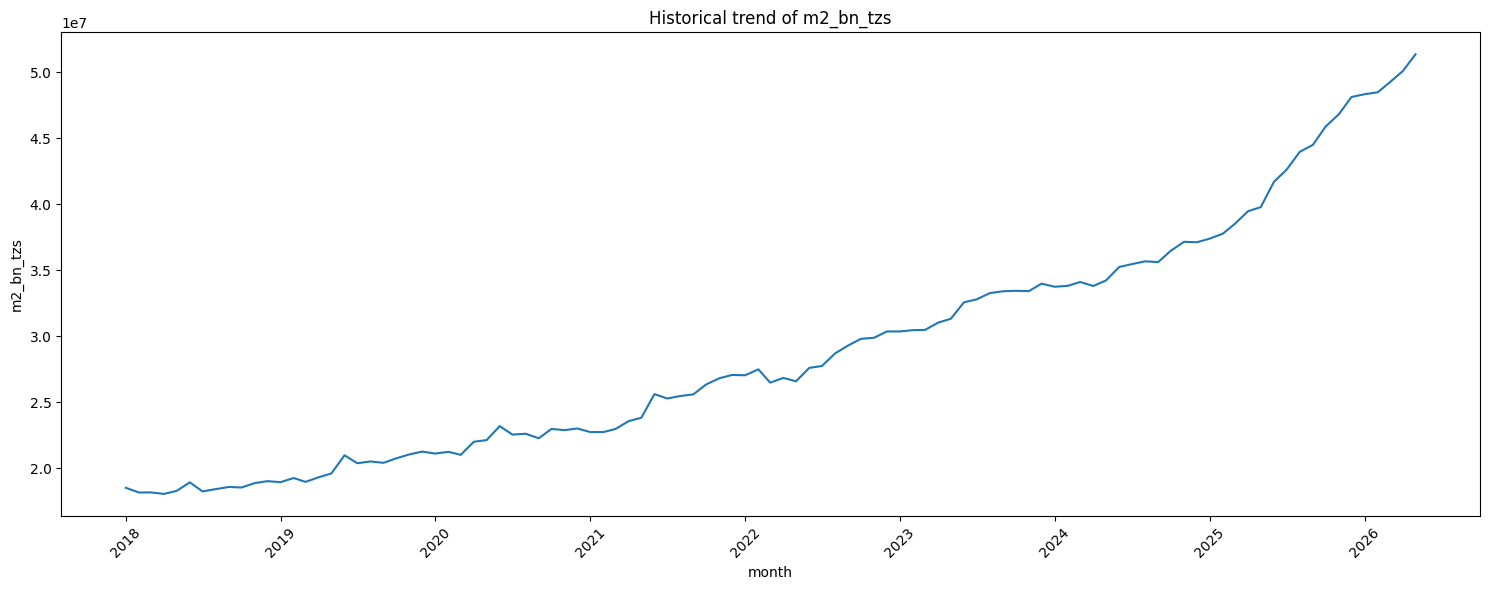

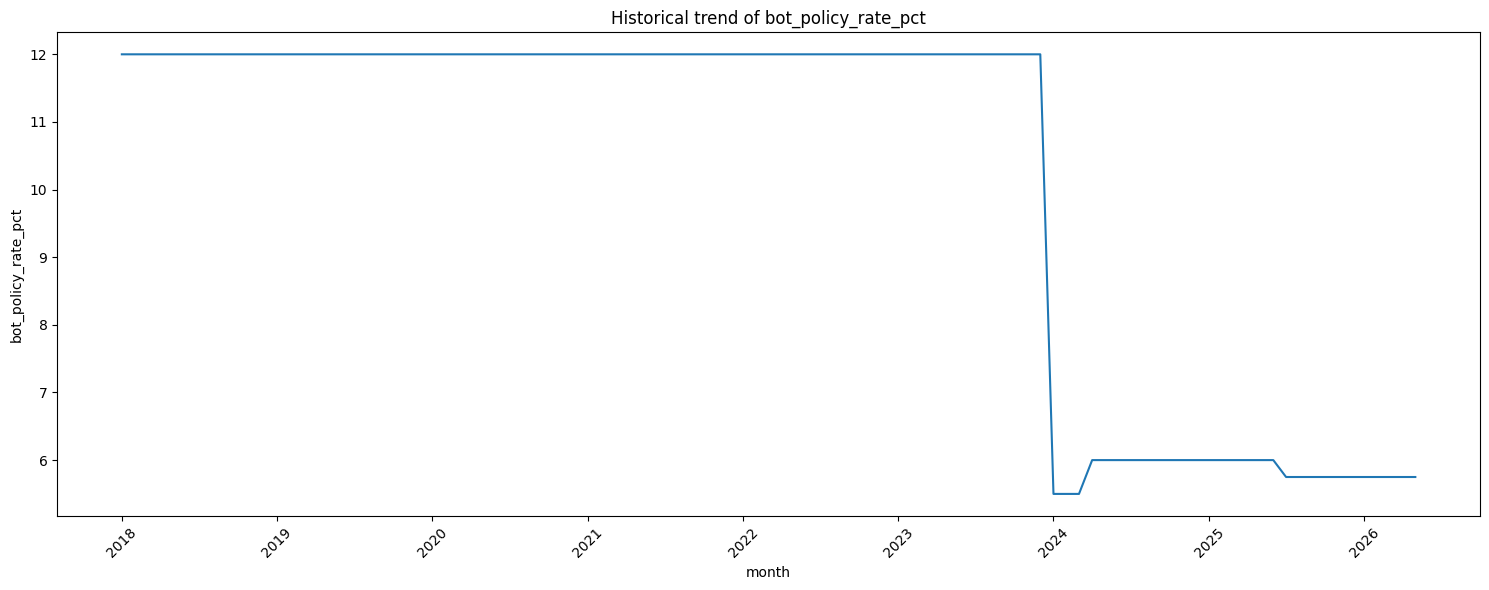

In [93]:
# Create a separate table for exploratory plots.
# The forecasting features are created later in the notebook.
eda_df = tzdata.copy()
eda_df["m2_growth"] = eda_df["m2_bn_tzs"].pct_change()

plot_columns = [
    "inflation_pct",
    "usd_tzs_rate",
    "brent_oil_usd",
    "m2_bn_tzs",
    "bot_policy_rate_pct"
]

for col in plot_columns:
    plt.figure(figsize=(15, 6))
    plt.plot(eda_df["month"], eda_df[col])
    plt.title(f"Historical trend of {col}")
    plt.xlabel("month")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

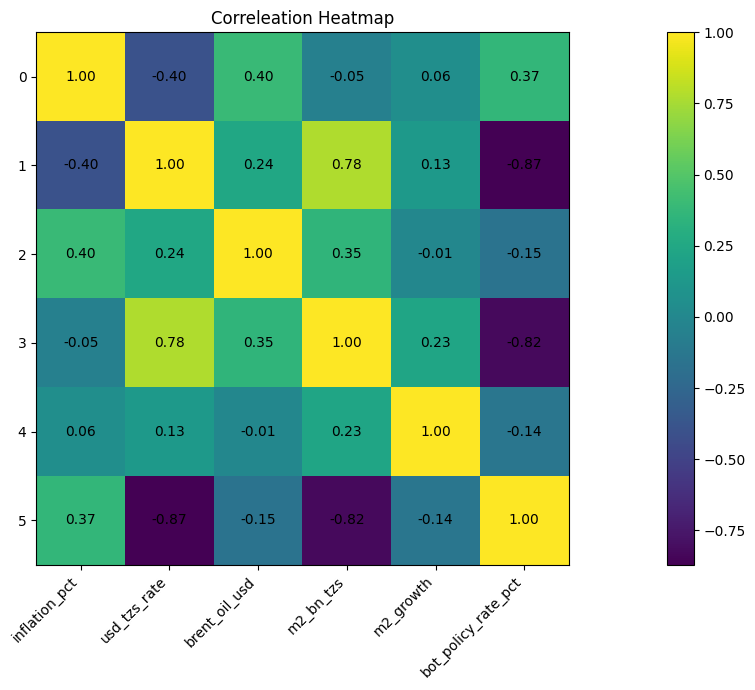

In [94]:
# correlation heatmap
corr_cols = [
    "inflation_pct",
    "usd_tzs_rate",
    "brent_oil_usd",
    "m2_bn_tzs",
    "m2_growth",
    "bot_policy_rate_pct"
]
# m2_growth_pct
corr = eda_df[corr_cols].dropna().corr()
plt.figure(figsize = (20,7))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation= 45, ha= "right")
plt.yticks(range(len(corr.columns)))
plt.title("Correleation Heatmap")

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j,i, f'{corr.iloc[i,j]:.2f}', ha = "center", va = "center")
        
plt.tight_layout()
plt.show()

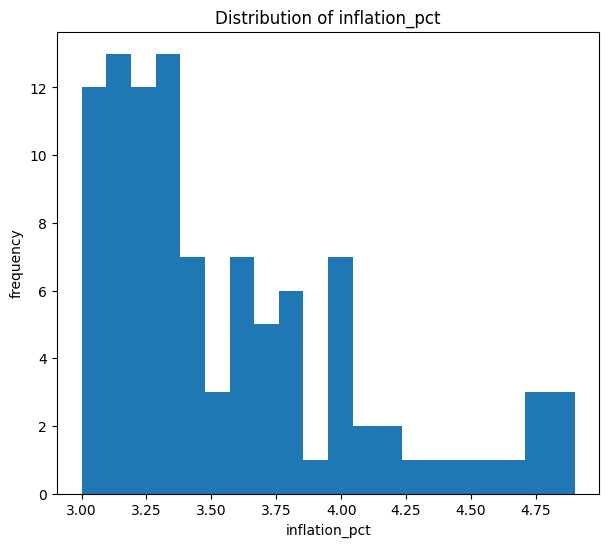

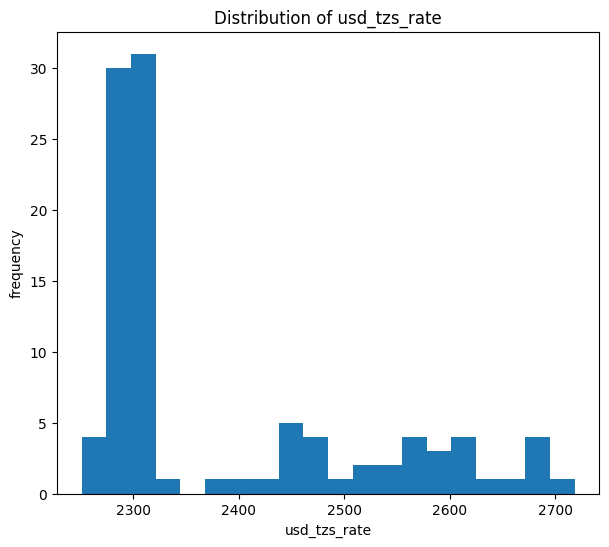

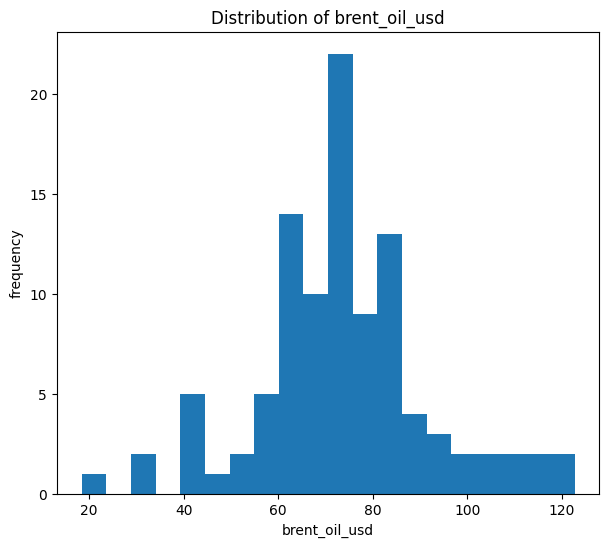

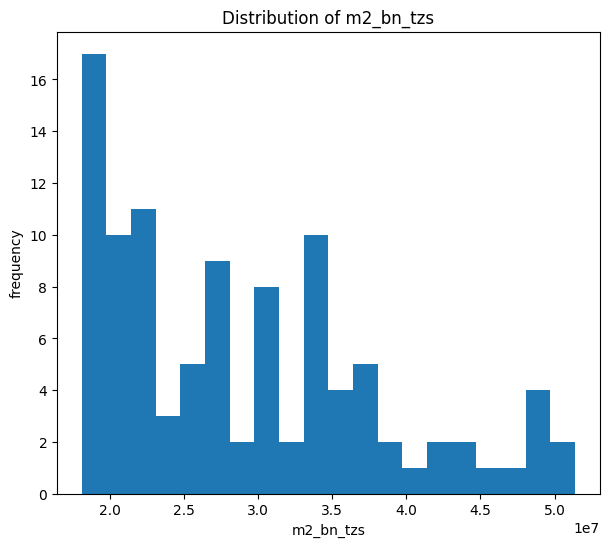

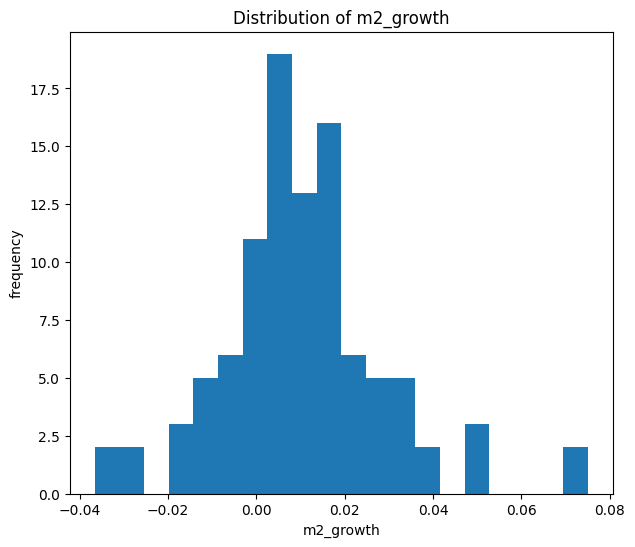

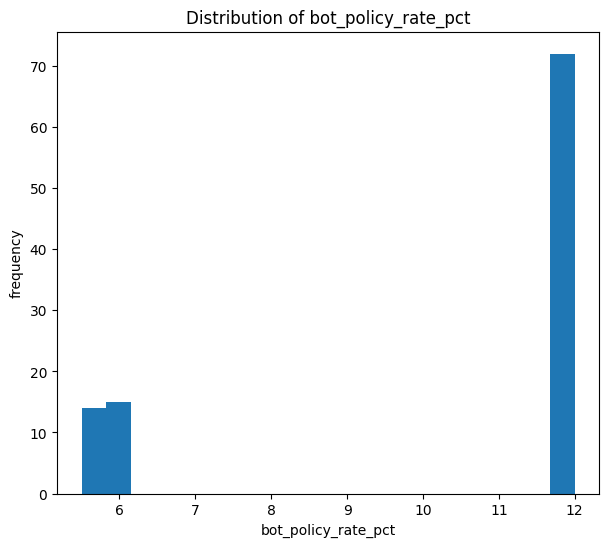

In [95]:
# Distribution plots
for col in corr_cols:
    plt.figure(figsize=(7,6))
    plt.hist(eda_df[col].dropna(), bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("frequency")
    plt.show()

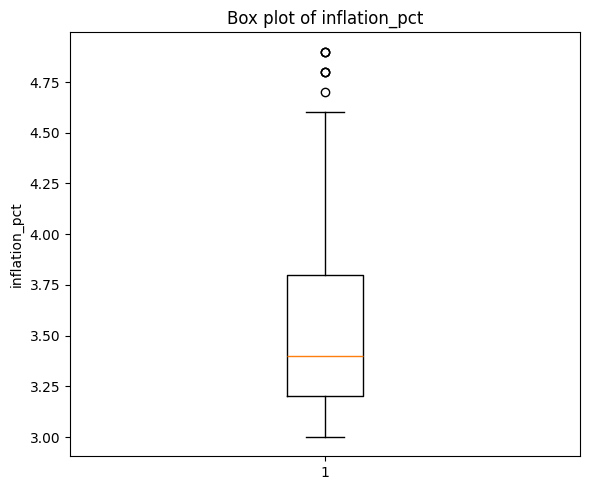

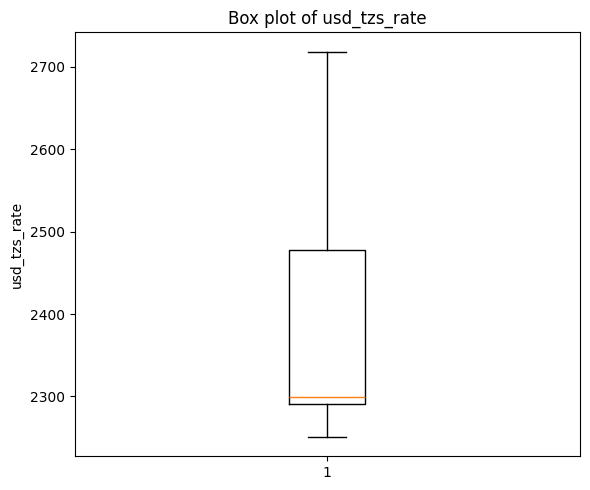

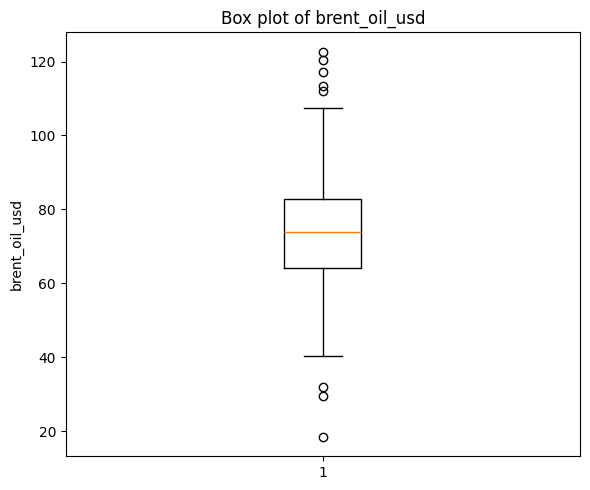

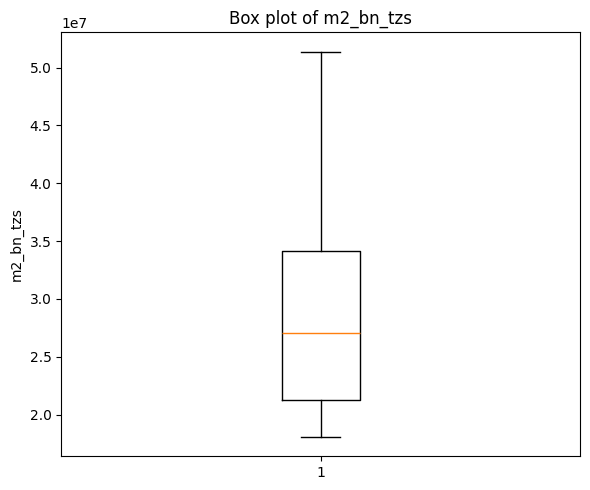

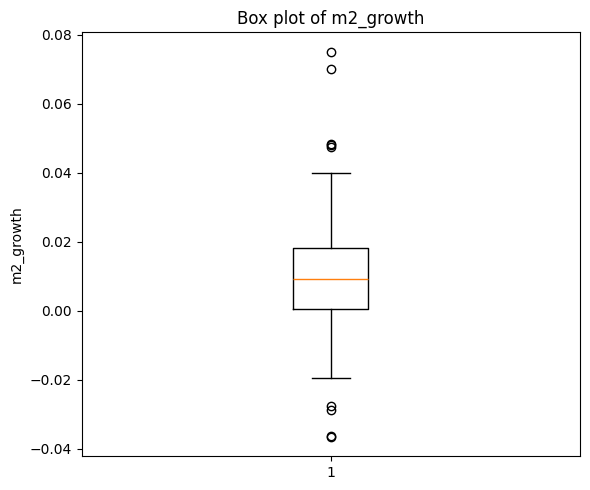

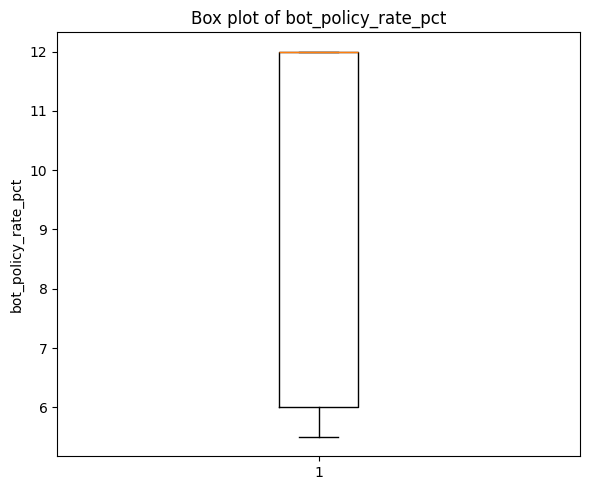

In [96]:
# Box Plot
for col in corr_cols:
    plt.figure(figsize=(6,5))
    plt.boxplot(eda_df[col].dropna())
    plt.title(f"Box plot of {col}")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# Feature Engineering

In [97]:
# Keep all observations in chronological order
tzdata = tzdata.sort_values("month").reset_index(drop=True)

# Inflation and money-supply history
tzdata["inflation_lag1"] = tzdata["inflation_pct"].shift(1)
tzdata["inflation_lag2"] = tzdata["inflation_pct"].shift(2)
tzdata["m2_growth"] = tzdata["m2_bn_tzs"].pct_change()
tzdata["m2_growth_lag1"] = tzdata["m2_growth"].shift(1)

# Model FX as a log return instead of an absolute TZS change
tzdata["usd_tzs_log_return"] = np.log(
    tzdata["usd_tzs_rate"] / tzdata["usd_tzs_rate"].shift(1)
)

# Detect a regime shock using only returns known before the current month
past_fx_returns = tzdata["usd_tzs_log_return"].shift(1)
rolling_fx_mean = past_fx_returns.rolling(window=24, min_periods=12).mean()
rolling_fx_std = past_fx_returns.rolling(window=24, min_periods=12).std()

tzdata["fx_regime_z"] = (
    tzdata["usd_tzs_log_return"] - rolling_fx_mean
) / rolling_fx_std
tzdata["fx_shock"] = (tzdata["fx_regime_z"].abs() > 3).astype(int)

# Winsorise the model input without changing the real published FX level
fx_input_lower = past_fx_returns.expanding(min_periods=12).quantile(0.01)
fx_input_upper = past_fx_returns.expanding(min_periods=12).quantile(0.99)
tzdata["usd_tzs_log_return_model"] = tzdata["usd_tzs_log_return"].clip(
    lower=fx_input_lower,
    upper=fx_input_upper
)
tzdata["usd_tzs_log_return_lag1"] = (
    tzdata["usd_tzs_log_return_model"].shift(1)
)

# Raw next-month outcomes are retained for honest evaluation
tzdata["inflation_next"] = tzdata["inflation_pct"].shift(-1)
tzdata["usd_tzs_log_return_next_raw"] = (
    tzdata["usd_tzs_log_return"].shift(-1)
)

# Limit extreme training targets using information available at forecast time
fx_target_lower = tzdata["usd_tzs_log_return"].expanding(
    min_periods=12
).quantile(0.01)
fx_target_upper = tzdata["usd_tzs_log_return"].expanding(
    min_periods=12
).quantile(0.99)
tzdata["usd_tzs_log_return_next"] = (
    tzdata["usd_tzs_log_return_next_raw"]
    .clip(lower=fx_target_lower, upper=fx_target_upper)
)

# Features used by the two required models
infl_features = [
    "inflation_pct",
    "inflation_lag1",
    "inflation_lag2",
    "brent_oil_usd",
    "m2_growth",
    "bot_policy_rate_pct"
]

fx_features = [
    "usd_tzs_log_return_model",
    "usd_tzs_log_return_lag1",
    "fx_shock",
    "brent_oil_usd",
    "m2_growth",
    "m2_growth_lag1",
    "bot_policy_rate_pct"
]

# The instructed notebook window is 2018-2024 only.
# 2025 onward stays in tzdata/live_collected_df for later comparison, but it is
# not used for model training, testing, or the automatic notebook forecast.
MODEL_START_DATE = pd.Timestamp("2018-01-01")
MODEL_END_DATE = pd.Timestamp("2024-12-01")
LIVE_START_DATE = MODEL_END_DATE + pd.offsets.MonthBegin(1)

tzdata["target_month"] = tzdata["month"] + pd.offsets.MonthBegin(1)
notebook_window_df = tzdata[
    (tzdata["month"] >= MODEL_START_DATE)
    & (tzdata["month"] <= MODEL_END_DATE)
].copy()

# Rows with known next-month targets are used for training and testing
required_model_columns = list(dict.fromkeys(
    infl_features
    + fx_features
    + ["inflation_next", "usd_tzs_log_return_next", "usd_tzs_log_return_next_raw"]
))
model_df = notebook_window_df.dropna(subset=required_model_columns).copy()
model_df = model_df[
    (model_df["target_month"] >= MODEL_START_DATE)
    & (model_df["target_month"] <= MODEL_END_DATE)
].reset_index(drop=True)

live_collected_df = tzdata[tzdata["month"] >= LIVE_START_DATE].copy()

# The latest 2018-2024 row has no allowed next-month target here, but it can
# still be used to forecast the next month without using 2025-2026 values.
forecast_input_df = notebook_window_df.dropna(
    subset=list(dict.fromkeys(infl_features + fx_features))
).reset_index(drop=True)

print(
    f"Model training/testing target months: "
    f"{MODEL_START_DATE:%b-%y} to {MODEL_END_DATE:%b-%y}"
)
print(f"Rows available for modelling: {len(model_df)}")
print(f"Rows kept as 2025+ live collected data, not model training/testing: {len(live_collected_df)}")
model_df.tail()

Model training/testing target months: Jan-18 to Dec-24
Rows available for modelling: 81
Rows kept as 2025+ live collected data, not model training/testing: 17


,month,inflation_pct,usd_tzs_rate,brent_oil_usd,m2_bn_tzs,bot_policy_rate_pct,inflation_lag1,inflation_lag2,m2_growth,m2_growth_lag1,usd_tzs_log_return,fx_regime_z,fx_shock,usd_tzs_log_return_model,usd_tzs_log_return_lag1,inflation_next,usd_tzs_log_return_next_raw,usd_tzs_log_return_next,target_month
76,2024-07-01,3.0,2673.9,85.30,35480597.14,6.0,3.1,3.1,0.006085,0.029756,0.017734,1.648835,0,0.017734,0.009947,3.1,0.002913,0.002913,2024-08-01
77,2024-08-01,3.1,2681.7,80.86,35693732.29,6.0,3.0,3.1,0.006007,0.006085,0.002913,-0.424743,0,0.002913,0.017734,3.1,0.013629,0.013629,2024-09-01
78,2024-09-01,3.1,2718.5,74.29,35636628.00,6.0,3.1,3.0,-0.001600,0.006007,0.013629,0.952961,0,0.013629,0.002913,3.0,-0.009387,-0.001736,2024-10-01
79,2024-10-01,3.0,2693.1,75.66,36498020.03,6.0,3.1,3.1,0.024172,-0.001600,-0.009387,-2.092796,0,-0.001736,0.013629,3.0,-0.027290,-0.003902,2024-11-01
80,2024-11-01,3.0,2620.6,74.40,37172493.60,6.0,3.0,3.1,0.018480,0.024172,-0.027290,-4.048991,1,-0.003902,-0.001736,3.1,-0.090104,-0.012789,2024-12-01


In [98]:
# Inspect the most recent FX movements and any detected regime shock
tzdata[
    [
        "month",
        "usd_tzs_rate",
        "usd_tzs_log_return",
        "fx_regime_z",
        "fx_shock"
    ]
].tail(8)

,month,usd_tzs_rate,usd_tzs_log_return,fx_regime_z,fx_shock
93,2025-10-01,2446.910516,-0.005189,-0.182996,0
94,2025-11-01,2437.127653,-0.004006,-0.130317,0
95,2025-12-01,2440.819516,0.001514,0.104067,0
96,2026-01-01,2467.820116,0.011001,0.461458,0
97,2026-02-01,2556.903379,0.035462,1.379080,0
98,2026-03-01,2570.410597,0.005269,0.185052,0
99,2026-04-01,2597.507093,0.010487,0.376619,0
100,2026-05-01,2602.516677,0.001927,0.055898,0


In [99]:
print("Inflation features:")
print(infl_features)

print("\nExchange-rate features:")
print(fx_features)

Inflation features:
['inflation_pct', 'inflation_lag1', 'inflation_lag2', 'brent_oil_usd', 'm2_growth', 'bot_policy_rate_pct']

Exchange-rate features:
['usd_tzs_log_return_model', 'usd_tzs_log_return_lag1', 'fx_shock', 'brent_oil_usd', 'm2_growth', 'm2_growth_lag1', 'bot_policy_rate_pct']


In [100]:
model_df.head()

,month,inflation_pct,usd_tzs_rate,brent_oil_usd,m2_bn_tzs,bot_policy_rate_pct,inflation_lag1,inflation_lag2,m2_growth,m2_growth_lag1,usd_tzs_log_return,fx_regime_z,fx_shock,usd_tzs_log_return_model,usd_tzs_log_return_lag1,inflation_next,usd_tzs_log_return_next_raw,usd_tzs_log_return_next,target_month
0,2018-03-01,3.9,2259.8,66.02,18189807.79,12.0,4.1,4.0,0.000556,-0.019537,0.001727,NaN,0,0.001727,0.002263,3.8,0.006088,0.006088,2018-04-01
1,2018-04-01,3.8,2273.6,72.11,18074492.88,12.0,3.9,4.1,-0.006340,0.000556,0.006088,NaN,0,0.006088,0.001727,3.6,0.001406,0.001406,2018-05-01
2,2018-05-01,3.6,2276.8,76.98,18304657.46,12.0,3.8,3.9,0.012734,-0.006340,0.001406,NaN,0,0.001406,0.006088,3.4,0.000395,0.000395,2018-06-01
3,2018-06-01,3.4,2277.7,74.41,18951216.54,12.0,3.6,3.8,0.035322,0.012734,0.000395,NaN,0,0.000395,0.001406,3.3,0.002149,0.002149,2018-07-01
4,2018-07-01,3.3,2282.6,74.25,18265656.36,12.0,3.4,3.6,-0.036175,0.035322,0.002149,NaN,0,0.002149,0.000395,3.3,0.001576,0.001576,2018-08-01


# Exchange Rate Model

In [101]:
# Predict the next-month FX log return
X_fx = model_df[fx_features]
y_fx = model_df["usd_tzs_log_return_next"]

# Chronological 80/20 split: future observations are never used to train the past
fx_split_point = int(len(model_df) * 0.8)
X_fx_train = X_fx.iloc[:fx_split_point]
X_fx_test = X_fx.iloc[fx_split_point:]
y_fx_train = y_fx.iloc[:fx_split_point]
y_fx_test = y_fx.iloc[fx_split_point:]

# Use the raw published outcomes when measuring model accuracy
current_fx_test_rates = model_df["usd_tzs_rate"].iloc[fx_split_point:].to_numpy()
actual_fx_test_returns = model_df[
    "usd_tzs_log_return_next_raw"
].iloc[fx_split_point:].to_numpy()
actual_next_month_rates = (
    current_fx_test_rates * np.exp(actual_fx_test_returns)
)

print(
    f"FX train rows: {len(X_fx_train)}, "
    f"test rows: {len(X_fx_test)}"
)

FX train rows: 64, test rows: 17


In [ ]:
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

fx_models = {}
fx_model_candidates = [
    ("Linear Regression", LinearRegression()),
    (
        "Random Forest",
        RandomForestRegressor(
            n_estimators=300,
            max_depth=4,
            random_state=42
        )
    )
]

for name, model in fx_model_candidates:
    model.fit(X_fx_train, y_fx_train)
    predicted_log_returns = model.predict(X_fx_test)
    predicted_levels = current_fx_test_rates * np.exp(predicted_log_returns)

    fx_models[name] = {
        "model": model,
        "preds": predicted_levels,
        "rmse": np.sqrt(mean_squared_error(actual_next_month_rates, predicted_levels)),
        "mae": mean_absolute_error(actual_next_month_rates, predicted_levels),
        "r2": r2_score(actual_next_month_rates, predicted_levels)
    }

    print(
        f"{name:18s}  "
        f"RMSE={fx_models[name]['rmse']:.2f} TZS  "
        f"MAE={fx_models[name]['mae']:.2f} TZS  "
        f"R2={fx_models[name]['r2']:.3f}"
    )

# A no-change forecast provides a simple benchmark
naive_fx_levels = current_fx_test_rates
print(
    f"{'No-change baseline':18s}  "
    f"RMSE={np.sqrt(mean_squared_error(actual_next_month_rates, naive_fx_levels)):.2f} TZS  "
    f"MAE={mean_absolute_error(actual_next_month_rates, naive_fx_levels):.2f} TZS  "
    # f"R2={r2_score(actual_next_month_rates, naive_fx_levels):.3f}"
)

Linear Regression   RMSE=62.18 TZS  MAE=35.94 TZS  R2=0.533
Random Forest       RMSE=62.10 TZS  MAE=35.29 TZS  R2=0.534
No-change baseline  RMSE=63.78 TZS  MAE=39.25 TZS  R2=0.509


In [103]:
# visulization of predicted value


# Inflation model

In [104]:
X_inflation = model_df[infl_features]
y_inflation = model_df["inflation_next"]

# Chronological 80/20 split
inflation_split_point = int(len(model_df) * 0.8)
X_inflation_train = X_inflation.iloc[:inflation_split_point]
X_inflation_test = X_inflation.iloc[inflation_split_point:]
y_inflation_train = y_inflation.iloc[:inflation_split_point]
y_inflation_test = y_inflation.iloc[inflation_split_point:]

print(
    f"Inflation train rows: {len(X_inflation_train)}, "
    f"test rows: {len(X_inflation_test)}"
)

Inflation train rows: 64, test rows: 17


In [ ]:
dates_test = model_df["month"].iloc[inflation_split_point:]

inflation_model_candidates = [
    ("Linear Regression", LinearRegression()),
    (
        "Random Forest",
        RandomForestRegressor(
            n_estimators=300,
            max_depth=4,
            random_state=42
        )
    )
]

inflation_models = {}

for name, model in inflation_model_candidates:
    model.fit(X_inflation_train, y_inflation_train)
    predictions = model.predict(X_inflation_test)

    rmse = np.sqrt(mean_squared_error(y_inflation_test, predictions))
    mae = mean_absolute_error(y_inflation_test, predictions)
    r2 = r2_score(y_inflation_test, predictions)

    inflation_models[name] = {
        "model": model,
        "preds": predictions,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    }

    print(
        f"{name:18s}  RMSE={rmse:.3f}%  "
        f"MAE={mae:.3f}%  R2={r2:.3f}"
    )

# Persistence is a useful baseline for monthly inflation
naive_inflation = model_df["inflation_pct"].iloc[inflation_split_point:].to_numpy()
print(
    f"{'Current-month baseline':18s}  "
    f"RMSE={np.sqrt(mean_squared_error(y_inflation_test, naive_inflation)):.3f}%  "
    f"MAE={mean_absolute_error(y_inflation_test, naive_inflation):.3f}%  "
    # f"R2={r2_score(y_inflation_test, naive_inflation):.3f}"
)

Linear Regression   RMSE=0.152%  MAE=0.130%  R2=-1.329
Random Forest       RMSE=0.177%  MAE=0.154%  R2=-2.147
Current-month baseline  RMSE=0.077%  MAE=0.047%  R2=0.410


# Reusable next-month prediction

In [107]:
# Train the final models on every row whose next-month outcome is known
final_inflation_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=4,
        random_state=42
    )
}

final_fx_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=4,
        random_state=42
    )
}

for model in final_inflation_models.values():
    model.fit(model_df[infl_features], model_df["inflation_next"])

for model in final_fx_models.values():
    model.fit(model_df[fx_features], model_df["usd_tzs_log_return_next"])

# Save the exact final Random Forest models used by the prediction functions
joblib.dump(final_inflation_models["Random Forest"], "infl_rf.joblib")
joblib.dump(final_fx_models["Random Forest"], "fx_rf.joblib")

print("Final models trained and saved.")

Final models trained and saved.


In [108]:
def build_prediction_table(current_month, current_fx_rate, inflation_row, fx_row):
    """Predict the month immediately after current_month."""
    forecast_period = pd.Timestamp(current_month).to_period("M") + 1
    forecast_label = forecast_period.strftime("%B %Y")

    inflation_predictions = {
        name: model.predict(inflation_row[infl_features])[0]
        for name, model in final_inflation_models.items()
    }

    fx_return_predictions = {
        name: model.predict(fx_row[fx_features])[0]
        for name, model in final_fx_models.items()
    }
    fx_level_predictions = {
        name: current_fx_rate * np.exp(predicted_return)
        for name, predicted_return in fx_return_predictions.items()
    }

    return pd.DataFrame({
        "Forecast Month": [forecast_label, forecast_label],
        "Target": ["Inflation (%)", "USD/TZS Exchange Rate"],
        "Linear Regression": [
            inflation_predictions["Linear Regression"],
            fx_level_predictions["Linear Regression"]
        ],
        "Random Forest": [
            inflation_predictions["Random Forest"],
            fx_level_predictions["Random Forest"]
        ]
    })


def predict_from_latest_data():
    """Automatically forecast the month after the latest dataset row."""
    latest_row = forecast_input_df.iloc[[-1]].copy()
    current_month = latest_row["month"].iloc[0]
    current_fx_rate = latest_row["usd_tzs_rate"].iloc[0]

    if latest_row["fx_shock"].iloc[0] == 1:
        print(
            "FX shock detected in the latest month. "
            "The published rate is preserved while its model input is capped."
        )

    return build_prediction_table(
        current_month=current_month,
        current_fx_rate=current_fx_rate,
        inflation_row=latest_row,
        fx_row=latest_row
    )


latest_next_month_prediction = predict_from_latest_data()
display(latest_next_month_prediction.round(2))

FX shock detected in the latest month. The published rate is preserved while its model input is capped.


,Forecast Month,Target,Linear Regression,Random Forest
0,January 2025,Inflation (%),3.12,3.09
1,January 2025,USD/TZS Exchange Rate,2386.82,2378.32


## Prediction interval for the Random Forest forecast

The dashboard shows a 95% interval around the point forecast. This is useful because the model prediction is not a guaranteed exact value. The interval is estimated from the Random Forest model errors on the chronological test set:

1. Calculate past residuals as `actual - predicted`.
2. Estimate the typical spread of those errors using the residual standard deviation.
3. Put a margin around the new forecast using `1.96 * residual_std`.

This should be interpreted as an approximate prediction interval, not a promise that the future official value must fall inside it. It is most useful when future economic conditions behave similarly to the historical test period.


In [112]:
def prediction_interval_95(point_prediction, residuals):
    """Approximate 95% prediction interval from previous model errors."""
    clean_residuals = np.asarray(residuals, dtype=float)
    clean_residuals = clean_residuals[np.isfinite(clean_residuals)]
    if len(clean_residuals) < 2:
        return (np.nan, np.nan)

    margin = 1.96 * np.std(clean_residuals, ddof=1)
    return (point_prediction - margin, point_prediction + margin)


# Residuals from the chronological test set, using the displayed target scale.
rf_inflation_residuals = (
    y_inflation_test.to_numpy(dtype=float)
    - inflation_models["Random Forest"]["preds"]
)
rf_fx_level_residuals = (
    actual_next_month_rates
    - fx_models["Random Forest"]["preds"]
)

rf_forecast = latest_next_month_prediction.set_index("Target")["Random Forest"]
inflation_point = float(rf_forecast["Inflation (%)"])
fx_point = float(rf_forecast["USD/TZS Exchange Rate"])

inflation_low, inflation_high = prediction_interval_95(
    inflation_point,
    rf_inflation_residuals
)
fx_low, fx_high = prediction_interval_95(
    fx_point,
    rf_fx_level_residuals
)

prediction_interval_summary = pd.DataFrame({
    # "Forecast Month": latest_next_month_prediction["Forecast Month"],
    "Target": latest_next_month_prediction["Target"],
    "Random Forest Prediction": [inflation_point, fx_point],
    "95% Lower Bound": [inflation_low, fx_low],
    "95% Upper Bound": [inflation_high, fx_high],
    # "How to read it": [
    #     "Approximate inflation range in percentage points",
    #     "Approximate exchange-rate range in TZS per USD"
    # ]
})

display(prediction_interval_summary.round(2))


,Target,Random Forest Prediction,95% Lower Bound,95% Upper Bound
0,Inflation (%),3.09,2.88,3.3
1,USD/TZS Exchange Rate,2378.32,2253.64,2503.0


In [110]:
def predict_with_own_values(
    current_month,
    inflation_pct,
    usd_tzs_rate,
    brent_oil_usd,
    m2_bn_tzs,
    bot_policy_rate_pct,
    previous_inflation_pct=None,
    inflation_two_months_ago=None,
    previous_usd_tzs_rate=None,
    previous_m2_bn_tzs=None,
    previous_fx_log_return=None,
    previous_m2_growth=None
):
    """
    Predict the month after current_month using values supplied by the user.

    Previous-month arguments are optional. When omitted, the latest available
    history in tzdata is used.
    """
    if usd_tzs_rate <= 0 or m2_bn_tzs <= 0:
        raise ValueError("USD/TZS and M2 values must be greater than zero.")

    latest = forecast_input_df.iloc[-1]

    previous_inflation_pct = (
        latest["inflation_pct"]
        if previous_inflation_pct is None
        else previous_inflation_pct
    )
    inflation_two_months_ago = (
        latest["inflation_lag1"]
        if inflation_two_months_ago is None
        else inflation_two_months_ago
    )
    previous_usd_tzs_rate = (
        latest["usd_tzs_rate"]
        if previous_usd_tzs_rate is None
        else previous_usd_tzs_rate
    )
    previous_m2_bn_tzs = (
        latest["m2_bn_tzs"]
        if previous_m2_bn_tzs is None
        else previous_m2_bn_tzs
    )
    previous_fx_log_return = (
        latest["usd_tzs_log_return_model"]
        if previous_fx_log_return is None
        else previous_fx_log_return
    )
    previous_m2_growth = (
        latest["m2_growth"]
        if previous_m2_growth is None
        else previous_m2_growth
    )

    if previous_usd_tzs_rate <= 0 or previous_m2_bn_tzs <= 0:
        raise ValueError("Previous USD/TZS and M2 values must be greater than zero.")

    current_fx_log_return = np.log(usd_tzs_rate / previous_usd_tzs_rate)
    historical_fx_returns = tzdata["usd_tzs_log_return"].dropna()
    recent_fx_returns = historical_fx_returns.tail(24)
    recent_fx_std = recent_fx_returns.std()
    current_fx_z = (
        (current_fx_log_return - recent_fx_returns.mean()) / recent_fx_std
        if recent_fx_std > 0
        else 0.0
    )
    current_fx_shock = int(abs(current_fx_z) > 3)

    fx_lower = historical_fx_returns.quantile(0.01)
    fx_upper = historical_fx_returns.quantile(0.99)
    current_fx_log_return_model = np.clip(
        current_fx_log_return,
        fx_lower,
        fx_upper
    )
    current_m2_growth = (m2_bn_tzs / previous_m2_bn_tzs) - 1

    prediction_row = pd.DataFrame([{
        "inflation_pct": inflation_pct,
        "inflation_lag1": previous_inflation_pct,
        "inflation_lag2": inflation_two_months_ago,
        "usd_tzs_rate": usd_tzs_rate,
        "usd_tzs_log_return_model": current_fx_log_return_model,
        "usd_tzs_log_return_lag1": previous_fx_log_return,
        "fx_shock": current_fx_shock,
        "brent_oil_usd": brent_oil_usd,
        "m2_growth": current_m2_growth,
        "m2_growth_lag1": previous_m2_growth,
        "bot_policy_rate_pct": bot_policy_rate_pct
    }])

    if current_fx_shock == 1:
        print(
            f"FX shock detected (z-score={current_fx_z:.2f}). "
            "The entered rate is preserved and only the model input is capped."
        )

    return build_prediction_table(
        current_month=current_month,
        current_fx_rate=usd_tzs_rate,
        inflation_row=prediction_row,
        fx_row=prediction_row
    )

In [111]:
def enter_values_and_predict():
    """Prompt for current-month values and display the following-month forecast."""
    current_month = input("Current month (YYYY-MM): ").strip()
    inflation_pct = float(input("Current inflation rate (%): "))
    usd_tzs_rate = float(input("Current USD/TZS rate: "))
    brent_oil_usd = float(input("Current Brent oil price (USD): "))
    m2_bn_tzs = float(input("Current M2 value: "))
    bot_policy_rate_pct = float(input("Current BOT policy rate (%): "))

    prediction = predict_with_own_values(
        current_month=current_month,
        inflation_pct=inflation_pct,
        usd_tzs_rate=usd_tzs_rate,
        brent_oil_usd=brent_oil_usd,
        m2_bn_tzs=m2_bn_tzs,
        bot_policy_rate_pct=bot_policy_rate_pct
    )
    display(prediction.round(2))
    return prediction


# Run this whenever you want to enter your own current-month values:
# manual_prediction = enter_values_and_predict()